In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import re
from pathlib import Path
from scipy import signal

In [2]:
DATA_DIR = Path("data/raw")

In [16]:
# Path.glob() returns a generator-like object, not a simple list, so you can't index it unless you first turn it into a list, either use sorted or list
#files = sorted(DATA_DIR.glob("*.hdf5")) # glob: finds all files ending with .hdf5
files = list(DATA_DIR.glob("*.hdf5"))

In [19]:
for file in files:
    print(file)

data/raw/H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5
data/raw/L-L1_GWOSC_4KHZ_R1-1264316101-32.hdf5


In [25]:
files[0].name

'H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5'

In [30]:
match = re.match(r".*-(\d+)-(\d+)\.hdf5$", files[0].name, flags=re.IGNORECASE)
file_start_gps = int(match.group(1)) # a group is a part of the matched text that’s captured by parentheses () in your regular expression.
file_duration = int(match.group(2))
print(files[0].name)
print(file_start_gps)
print(file_duration)

H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5
1264316101
32


# HDF5

- HDF5 is like a folder system inside a single file.
- Groups you’ll see:
    strain: where the actual data lives.
    meta: metadata.
    quality: flags.
- strain/Strain: the raw signal, 1D array of floats.

In [38]:
path = files[0]
with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nInside 'Strain':", list(f["strain"].keys()))
    
    dset = f["strain"]["Strain"]
    print("Shape:", dset.shape)
    print("Data type:", dset.dtype)
    print("First 10 samples:", dset[:10])
    print("DSET Type:", type(dset))
    #print(dset[:])

Top-level keys: ['meta', 'quality', 'strain']

Inside 'Strain': ['GWOSCmeta', 'Strain']
Shape: (131072,)
Data type: float64
First 10 samples: [7.78093662e-21 1.18189890e-20 1.68268607e-20 1.09831546e-20
 4.77022809e-21 1.61422452e-20 1.93075218e-20 9.89761838e-21
 9.94420316e-21 1.36436917e-20]
DSET Type: <class 'h5py._hl.dataset.Dataset'>


In [44]:
with h5py.File(path, "r") as f:
    strain = f["strain"]["Strain"][:]

In [45]:
strain

array([ 7.78093662e-21,  1.18189890e-20,  1.68268607e-20, ...,
       -3.39502926e-20, -2.47413697e-20, -3.03693951e-20])

In [46]:
type(strain)

numpy.ndarray

In [51]:
N = len(strain)
print("Samples:", N)

Samples: 131072


In [52]:
strain.shape

(131072,)

In [53]:
strain = np.nan_to_num(strain)

In [54]:
print("Duration:", N/4096)

Duration: 32.0


In [56]:
strain.itemsize

8

### Here’s how size is calculated in that code, step by step, briefly:
1. N = len(strain) → Counts how many samples are in strain.
2. strain.itemsize → Size of one element in bytes (e.g., 8 bytes for a float64).
3. N * strain.itemsize → Total bytes used by all samples.
4. / 1024**2 → Converts bytes to megabytes (MB).

In [57]:
print(f"Approx memory: {N * strain.itemsize / 1024**2:.1f} MB")

Approx memory: 1.0 MB


In [63]:
# Lok at 15.7-16.3 seconds in the file
t0 = 15.7
t1 = 16.3

i0 = int(15.7 * 4096) # index of 15.7s
i1 = int(16.3 * 4096) # index of 16.3s

segment = strain[i0:i1]
time_axis = np.arange(i0, i1) / 4096

print("Indecies:", i0, "-", i1)
print("Segment length:", len(segment))

Indecies: 64307 - 66764
Segment length: 2457


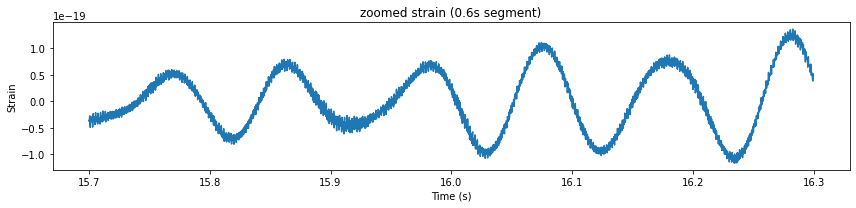

In [71]:
plt.figure(figsize=(12, 3))
plt.plot(time_axis, segment)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("zoomed strain (0.6s segment)")
plt.tight_layout() # plt.tight_layout() in Matplotlib automatically adjusts the spacing of your plot so labels, titles, and ticks don’t overlap or get cut off.
plt.show()

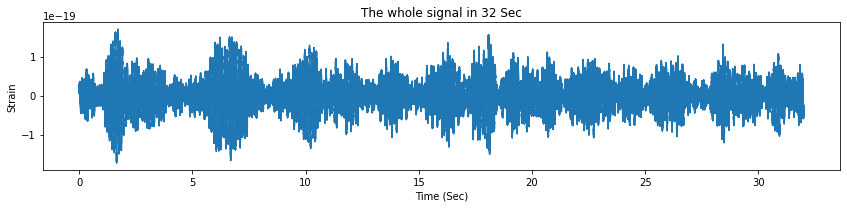

In [70]:
# Plot the whole signal
y_axis = strain[:]
time_ax = np.arange(0, len(strain)) / 4096

plt.figure(figsize=(12, 3))
plt.plot(time_ax, y_axis)
plt.xlabel("Time (Sec)")
plt.ylabel("Strain")
plt.title("The whole signal in 32 Sec")
plt.tight_layout()
plt.show()

## Matplotlib Object Oriented Method
Now that we've seen the basics, let's break it all down with a more formal introduction of Matplotlib's Object Oriented API. This means we will instantiate figure objects and then call methods or attributes from that object.

axes2 = fig.add_axes([0.2, 0.5, 0.25, 0.25])
- Starts 20% from left, 50% from bottom
- width = 25% of figure, height = 25%

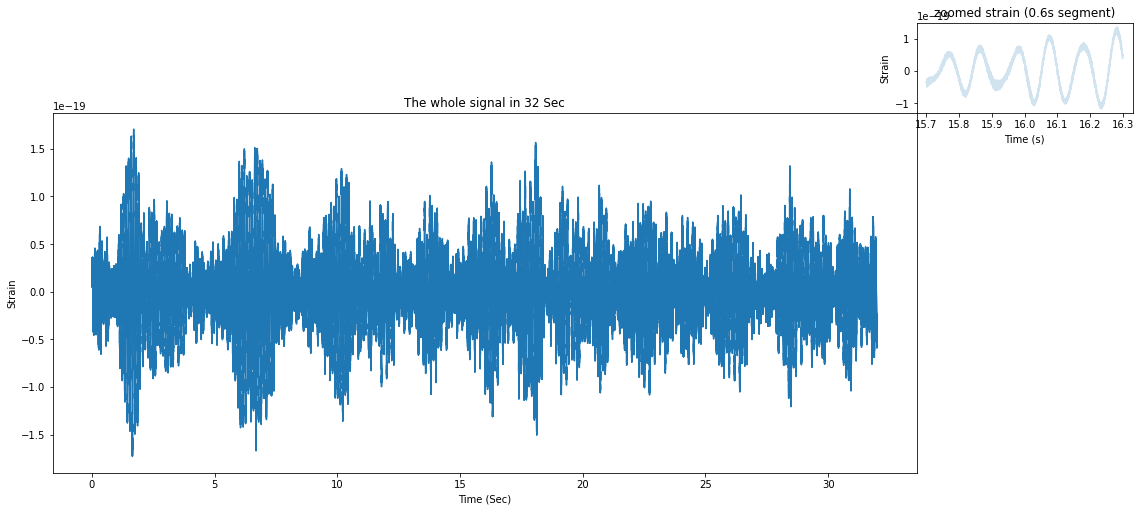

In [135]:
fig = plt.figure(figsize=(12, 5))
axes1 = fig.add_axes([0, 0, 1, 1]) # Large figure, # left, bottom, width, height (range 0 to 1)
#axes2 = fig.add_axes([0.01, 0.7, 0.25, 0.25]) # Small figure
axes2 = fig.add_axes([1, 1, 0.25, 0.25])
axes1.plot(time_ax, y_axis, alpha=1)
axes1.set_xlabel("Time (Sec)")
axes1.set_ylabel("Strain")
axes1.set_title("The whole signal in 32 Sec")

axes2.plot(time_axis, segment, alpha=0.2) # Alpha Keyword argument is saying now half transparent 
axes2.set_xlabel("Time (s)")
axes2.set_ylabel("Strain")
axes2.set_title("zoomed strain (0.6s segment)")
plt.show()

Text(0.5, 1.0, 'The whole signal in 32 Sec')

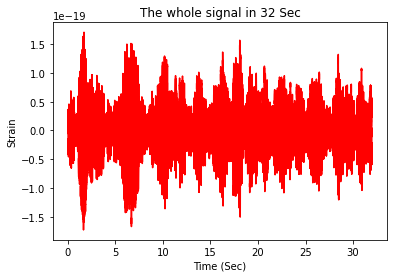

In [121]:
fig, axes = plt.subplots()

axes.plot(time_ax, y_axis, 'r')
axes.set_xlabel("Time (Sec)")
axes.set_ylabel("Strain")
axes.set_title("The whole signal in 32 Sec")

**NOTE:** A common issue with matplolib is overlapping subplots or figures. We ca use fig.tight_layout() or plt.tight_layout() method, which automatically adjusts the positions of the axes

### LEGEND
- ax.legend(loc=1) # upper right corner
- ax.legend(loc=2) # upper left corner
- ax.legend(loc=3) # lower left corner
- ax.legend(loc=4) # lower right corner

[<AxesSubplot:> <AxesSubplot:>]
(2,)


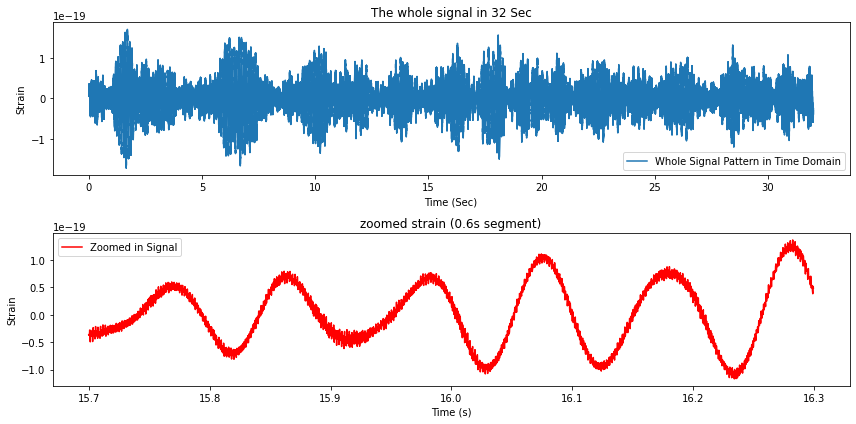

In [125]:
fig, axes = plt.subplots(nrows = 2, ncols=1, figsize=(12, 6))
print(axes)
print(axes.shape)
axes[0].plot(time_ax, y_axis, label="Whole Signal Pattern in Time Domain")
axes[0].legend() # Used along with label
axes[0].set_xlabel("Time (Sec)")
axes[0].set_ylabel("Strain")
axes[0].set_title("The whole signal in 32 Sec")

axes[1].plot(time_axis, segment, 'r', label="Zoomed in Signal")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Strain")
axes[1].set_title("zoomed strain (0.6s segment)")
axes[1].legend()

plt.tight_layout() # Try without it to see the difference
#fig.tight_layout()

# Fast Fourier Transform (FFT)
d is the sample spacing (seconds per sample).
Since your sample rate is 4096 Hz, each sample is 1/4096 seconds apart.

In [137]:
freqs = np.fft.rfftfreq(N, d=1/4096)

In [138]:
type(freqs)

numpy.ndarray

In [139]:
freqs

array([0.00000000e+00, 3.12500000e-02, 6.25000000e-02, ...,
       2.04793750e+03, 2.04796875e+03, 2.04800000e+03])

In [140]:
fft_vals = np.abs(np.fft.rfft(strain))

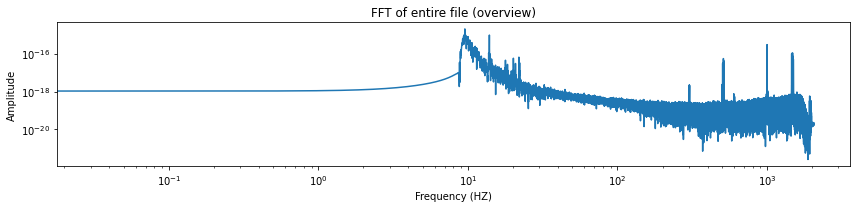

In [142]:
plt.figure(figsize=(12, 3))
plt.loglog(freqs, fft_vals)
plt.xlabel("Frequency (HZ)")
plt.ylabel("Amplitude")
plt.title("FFT of entire file (overview)")
plt.tight_layout()
plt.show()

In [143]:
#1264316116.4
print(file_start_gps)

1264316101


In [166]:
event_gps = 1264316116.4
event_time = event_gps - file_start_gps

In [167]:
print(f"Event happend {event_time}")

Event happend 15.400000095367432


In [153]:
FS = 4096
i_event = event_time * FS

In [155]:
int(i_event)

63078

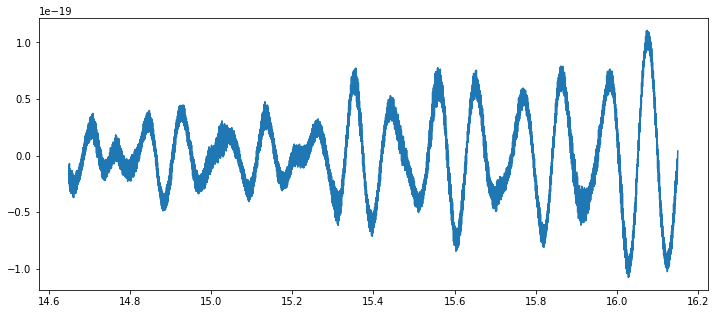

In [172]:
FS = 4096

event_time = event_gps - file_start_gps


start_event = int((event_time - 0.75) * FS) 
end_event = int((event_time + 0.75) * FS)


segment = strain[start_event:end_event]
t = np.arange(start_event, end_event) / FS

fig = plt.figure(figsize=(12, 5))
plt.plot(t, segment)

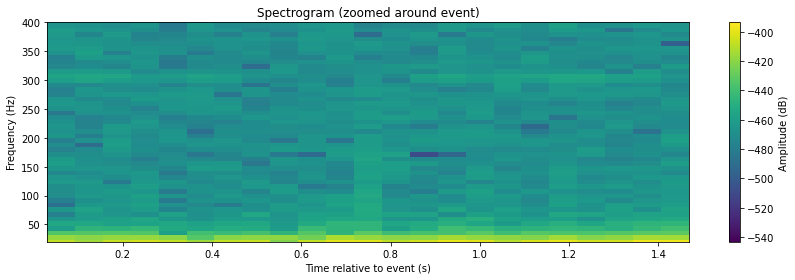

In [173]:
# Use the same segment around the event from Cell B
# (seg, centered time axis t_seg)
# If you didn't run Cell B, compute seg again as above.

plt.figure(figsize=(12,4))
Pxx, freqs_s, bins_s, im = plt.specgram(
    segment + 1e-20,            # tiny epsilon to avoid log(0) warnings
    NFFT=512,               # window length for each mini-FFT (trade-off time vs freq resolution)
    Fs=FS,
    noverlap=256,           # 50% overlap increases smoothness
    cmap="viridis",
    scale="dB"              # show color in decibels (easier to see contrasts)
)
# Convert spectrogram bin times from "seconds since seg start" to "relative to event"
plt.xlabel("Time relative to event (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram (zoomed around event)")
plt.ylim(20, 400)           # focus on GW band; adjust as needed
plt.colorbar(label="Amplitude (dB)")
plt.tight_layout(); plt.show()


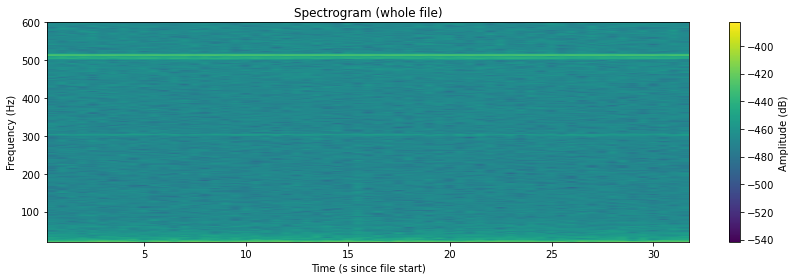

In [174]:
plt.figure(figsize=(12,4))
Pxx, freqs_w, bins_w, im = plt.specgram(
    strain[:len(strain)],   # whole file
    NFFT=4096,              # longer window because we want broad context
    Fs=FS,
    noverlap=2048,
    cmap="viridis",
    scale="dB"
)
plt.xlabel("Time (s since file start)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram (whole file)")
plt.ylim(20, 600)           # keep it readable; adjust as needed
plt.colorbar(label="Amplitude (dB)")
plt.tight_layout(); plt.show()
